In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
MAX_FEATURES =500
# Load the images
img1 = cv2.imread('apple-color.jpg', cv2.COLOR_BGR2GRAY)
img2 = cv2.imread('apple-color2.jpg', cv2.COLOR_BGR2GRAY)
img2normal = cv2.imread('apple-color2.jpg')



In [61]:
# Initialize ORB detector
orb = cv2.ORB_create(MAX_FEATURES)

# Detect keypoints and descriptors
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

GOOD_MATCH_PERCENT = 30
# Match features.
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = list(matcher.match(des1, des2, None))

# Sort matches by score
matches.sort(key=lambda x: x.distance, reverse=False)

numGoodMatches = int(len(matches) * GOOD_MATCH_PERCENT)
matches = matches[:numGoodMatches]

print(matches)


# Draw top matches
imMatches = cv2.drawMatches(img1, kp1, img2, kp2, matches, None)
cv2.imwrite("matches.jpg", imMatches)

# Extract location of good matches
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = kp1[match.queryIdx].pt
    points2[i, :] = kp2[match.trainIdx].pt

[< cv2.DMatch 0x7f257c7f41b0>, < cv2.DMatch 0x7f257c7f4590>, < cv2.DMatch 0x7f257c7f4a30>, < cv2.DMatch 0x7f257c7f4d50>, < cv2.DMatch 0x7f257c7f4a50>, < cv2.DMatch 0x7f257c7f4d70>, < cv2.DMatch 0x7f257c7f4bf0>, < cv2.DMatch 0x7f257c7f4bd0>, < cv2.DMatch 0x7f257c7f4f10>, < cv2.DMatch 0x7f257c7f50f0>, < cv2.DMatch 0x7f257c7f4730>, < cv2.DMatch 0x7f257c7f4f30>, < cv2.DMatch 0x7f257c7f52b0>, < cv2.DMatch 0x7f257c7f5450>, < cv2.DMatch 0x7f257c7f4a70>, < cv2.DMatch 0x7f257c7f4d90>, < cv2.DMatch 0x7f257c7f4f50>, < cv2.DMatch 0x7f257c7f5110>, < cv2.DMatch 0x7f257c7f5290>, < cv2.DMatch 0x7f257c7f50d0>, < cv2.DMatch 0x7f257c7f52d0>, < cv2.DMatch 0x7f257c7f5470>, < cv2.DMatch 0x7f257c7f4df0>, < cv2.DMatch 0x7f257c7f5170>, < cv2.DMatch 0x7f257c7f4950>, < cv2.DMatch 0x7f257c7f51d0>, < cv2.DMatch 0x7f257c7f4fb0>, < cv2.DMatch 0x7f257c7f4ad0>, < cv2.DMatch 0x7f257c7f4c50>, < cv2.DMatch 0x7f257c7f5030>, < cv2.DMatch 0x7f257c7f5050>, < cv2.DMatch 0x7f257c7f51f0>, < cv2.DMatch 0x7f257c7f5210>, < cv2.DMa

In [69]:
print(points1[:5])
print("debug--------------------------")
print(points2[:5])

[[459.      303.     ]
 [462.      304.     ]
 [458.40002 302.40002]
 [457.92004 302.40002]
 [462.00003 303.6    ]]
debug--------------------------
[[361. 429.]
 [362. 426.]
 [361. 429.]
 [361. 429.]
 [362. 426.]]


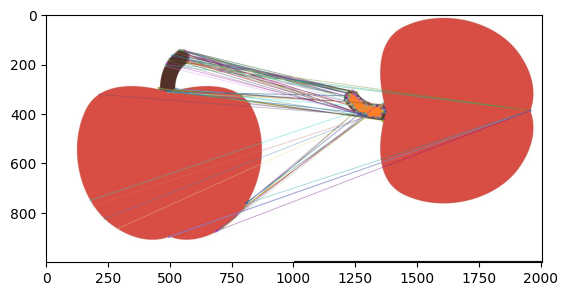

In [62]:
imgmatched = plt.imread("matches.jpg")
plt.imshow(imgmatched)

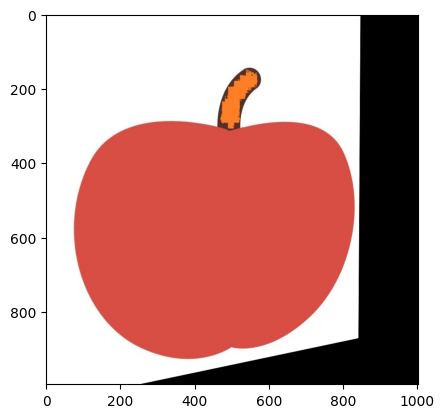

In [63]:
h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)
height, width, channels = img2.shape
im1Reg = cv2.warpPerspective(img2normal, h, (width, height))
cv2.imwrite("imgrewrite.jpg", im1Reg)
imgshow = plt.imread("imgrewrite.jpg")
plt.imshow(imgshow)

In [76]:
matcherv2 = cv2.BFMatcher(cv2.NORM_HAMMING2)
matcher2S = matcherv2.knnMatch(des1, des2, k=2)
ratio = 0,75 # extract only 75% neighbor

# Apply Lowe's ratio test with 0.75 threshold
matcher2SResult = []
for m, n in matcher2S:
    if m.distance < 0.75 * n.distance:
        matcher2SResult.append(m)

print(matcher2SResult)


# Draw top matches
imMatches = cv2.drawMatches(img1, kp1, img2, kp2, matches, None)
cv2.imwrite("matches2.jpg", imMatches)


[< cv2.DMatch 0x7f257c2732d0>, < cv2.DMatch 0x7f257c2736d0>, < cv2.DMatch 0x7f257c273650>, < cv2.DMatch 0x7f257c272450>, < cv2.DMatch 0x7f257c270050>, < cv2.DMatch 0x7f257c272370>, < cv2.DMatch 0x7f257c4396d0>, < cv2.DMatch 0x7f257c438770>, < cv2.DMatch 0x7f257c438290>, < cv2.DMatch 0x7f257c438930>, < cv2.DMatch 0x7f257c4380b0>, < cv2.DMatch 0x7f257c439910>, < cv2.DMatch 0x7f257c439e90>, < cv2.DMatch 0x7f257c43aa70>, < cv2.DMatch 0x7f257c4384d0>, < cv2.DMatch 0x7f257c43a4d0>, < cv2.DMatch 0x7f257c43ab70>, < cv2.DMatch 0x7f257c43a010>, < cv2.DMatch 0x7f257c43a470>, < cv2.DMatch 0x7f257c438090>, < cv2.DMatch 0x7f257c43acd0>, < cv2.DMatch 0x7f257c438150>, < cv2.DMatch 0x7f257c43b030>]


True